# Clasificación de polaridad en TASS 2018 — Fases 0, 2, 3 y 4

Partimos del baseline del taller (BoW + Softmax) y lo ampliamos con las características léxicas del grupo.

| Fase | Qué se hace |
|---|---|
| 0 | Auditoría de las características existentes |
| 2 | Tres representaciones: TF-IDF, léxica y la unión |
| 3 | Selección del clasificador con validación cruzada (macro-F1) |
| 4 | Ablación, evaluación final en test, errores y limitaciones |

**Regla del trabajo: cero fuga de información.** Todo se decide con validación cruzada sobre el
train. El conjunto de test se carga **una sola vez**, en la sección 5, con el modelo ya elegido.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk import TweetTokenizer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, ConfusionMatrixDisplay, f1_score)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler, StandardScaler
from sklearn.svm import LinearSVC
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

ROOT = Path.cwd() if (Path.cwd() / 'logic').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
from logic.feature_extraction import FeatureExtraction
from logic.representations import LexicalFeatures, ORIGINAL_NAMES, ALL_NAMES, AUTHORS, clean_text, lexical_text

warnings.filterwarnings('ignore', category=FutureWarning)
SEED = 42
np.random.seed(SEED)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 110)
COL_TEXT, COL_LABEL = 'content', 'sentiment/polarity/value'
CLASSES = ['N', 'NEU', 'NONE', 'P']

train = pd.read_csv(ROOT / 'data' / 'tass' / 'tass2018_es_train.csv').dropna(subset=[COL_TEXT]).reset_index(drop=True)
y_train = train[COL_LABEL].str.strip().str.upper().to_numpy()
print(f'train: {len(train)} tweets')
pd.Series(y_train).value_counts().reindex(CLASSES).to_frame('tweets').T

train: 1008 tweets


,N,NEU,NONE,P
tweets,418,133,139,318


El corpus está **desbalanceado**: N es la clase mayoritaria y NEU/NONE juntas apenas pasan del 25 %.
Por eso el criterio de selección es **macro-F1** (promedia las cuatro clases por igual) y no accuracy.

## 1. Fase 0 — Auditoría de las características existentes

Para cada una de las 29 características de `get_features_lexical()` medimos sobre el train:

- **(a) Constante:** en qué % de tweets vale distinto de 0. Si es menos del 1 % se considera constante.
- **(b) Proxy de longitud:** correlación de Pearson con el número de tokens. Si |r| > 0.9, la característica
  solo repite la longitud del tweet.
- **(c) Orden del preprocesamiento:** % de activación si el texto pasa por `transformer()` (el
  preprocesamiento oficial) frente a una variante que conserva tildes, emojis y etiquetas.

In [2]:
fe = FeatureExtraction('es')
tok = TweetTokenizer()

def lexical_matrix(texts):
    return np.array([fe.get_features_lexical(t) if t else np.zeros(len(ORIGINAL_NAMES)) for t in texts])[:, :len(ORIGINAL_NAMES)]

txt_transformer = [clean_text(t) for t in train[COL_TEXT]]
txt_variante = [lexical_text(t) for t in train[COL_TEXT]]
M_transformer = lexical_matrix(txt_transformer)
M_variante = lexical_matrix(txt_variante)
n_tokens = np.array([len(tok.tokenize(t)) for t in txt_variante])

audit = pd.DataFrame({
    '% activa (transformer)': (M_transformer != 0).mean(0) * 100,
    '% activa (variante)': (M_variante != 0).mean(0) * 100,
    'r con n_tokens': [np.corrcoef(M_variante[:, j], n_tokens)[0, 1] if M_variante[:, j].std() > 0 else np.nan
                       for j in range(len(ORIGINAL_NAMES))],
}, index=ORIGINAL_NAMES).round(3)
audit['(a) constante'] = audit['% activa (variante)'] < 1
audit['(b) proxy longitud'] = audit['r con n_tokens'].abs() > 0.9
audit['(c) la rompe transformer'] = (audit['% activa (transformer)'] == 0) & (audit['% activa (variante)'] > 0)
audit

,% activa (transformer),% activa (variante),r con n_tokens,(a) constante,(b) proxy longitud,(c) la rompe transformer
weighted_position,100.000,100.000,0.715,False,False,False
weighted_normalized,100.000,100.000,0.985,False,True,False
label_mention,63.393,63.591,0.064,False,False,False
label_url,3.274,3.274,0.017,False,False,False
label_hashtag,0.000,7.143,0.042,False,False,True
label_emoji,0.000,3.274,0.049,False,False,True
label_retweets,0.397,0.397,0.022,True,False,False
lexical_diversity,100.000,100.000,-0.821,False,False,False
label_word,100.000,100.000,0.983,False,True,False
first_person_singular,17.857,17.262,0.149,False,False,False


In [3]:
def motivo(row):
    if row['(a) constante']:
        return 'constante (<1 % de tweets)'
    if row['(b) proxy longitud']:
        return f"proxy de longitud (r = {row['r con n_tokens']:.2f})"
    return None

audit['decisión'] = audit.apply(lambda r: 'excluir: ' + motivo(r) if motivo(r) else 'mantener', axis=1)
print('Rotas por transformer() y recuperadas con la variante:',
      audit.index[audit['(c) la rompe transformer']].tolist())
audit.loc[audit['decisión'] != 'mantener', ['% activa (variante)', 'r con n_tokens', 'decisión']]

Rotas por transformer() y recuperadas con la variante: ['label_hashtag', 'label_emoji']


,% activa (variante),r con n_tokens,decisión
weighted_normalized,100.000,0.985,excluir: proxy de longitud (r = 0.98)
label_retweets,0.397,0.022,excluir: constante (<1 % de tweets)
label_word,100.000,0.983,excluir: proxy de longitud (r = 0.98)
first_person_plurar,0.694,0.002,excluir: constante (<1 % de tweets)
second_person_plurar,0.694,0.070,excluir: constante (<1 % de tweets)
who_general,0.893,0.001,excluir: constante (<1 % de tweets)


**Resultado de la auditoría.**

- **(c) Dos características estaban rotas por el orden del preprocesamiento.** Con `transformer()`,
  `label_hashtag` y `label_emoji` valen 0 en el 100 % de los tweets: el preprocesamiento escribe
  `[HASTAG]` y borra los emojis al pasar el texto a ASCII, mientras que `get_features_lexical()` busca
  `hashtag` y `emoji`. **Corrección:** las léxicas se calculan sobre `lexical_text()`, la variante del
  notebook del taller que conserva tildes y deja `hashtag`, `mention`, `url` y `emoji` como palabras. Con
  ella se activan en el 7.1 % y el 3.3 % de los tweets.
- **(b) Dos son proxies de longitud:** `label_word` (r = 0.98, es el conteo de tokens) y
  `weighted_normalized` (r = 0.98). Se excluyen. `lexical_diversity` (r = −0.82) queda por debajo del
  umbral y se mantiene.
- **(a) Cuatro son prácticamente constantes** (menos del 1 % de los tweets): `label_retweets`,
  `first_person_plurar`, `second_person_plurar` y `who_general`. Se excluyen.

## 2. Fase 1 — Características nuevas del grupo

Integrantes: Sebastián Sarmiento, Zuly González y Daniel Contreras. Cada uno implementó sus características
en `logic/feature_extraction.py` y las probó con tweets reales en `tests/`. Aquí aplicamos a las nuevas el mismo filtro de la Fase 0 y vemos su media por clase.

In [4]:
lex = LexicalFeatures().fit(train[COL_TEXT])
L_train = pd.DataFrame(lex.transform(train[COL_TEXT]), columns=ALL_NAMES)

rows = []
for author, cols in AUTHORS.items():
    for c in cols:
        rows.append({'autor': author, 'característica': c, '% activa': round((L_train[c] != 0).mean() * 100, 1),
                     **L_train[c].groupby(y_train).mean().round(3).to_dict()})
nuevas = pd.DataFrame(rows).set_index(['autor', 'característica'])
nuevas['decisión'] = np.where(nuevas['% activa'] < 1, 'excluir: constante (<1 %)', 'mantener')
nuevas

% activa      N    NEU   NONE      P  decisión
autor               característica                                                   
Sebastian Sarmiento emoji_count             3.3  0.022  0.075  0.036  0.094  mantener
                    emoji_pol               2.9  0.012  0.023  0.014  0.079  mantener
                    laugh_count             3.7  0.041  0.038  0.022  0.038  mantener
                    laugh_len               3.7  0.364  0.195  0.065  0.264  mantener
                    lex_pol_neg            61.9 -0.044  0.054  0.053  0.159  mantener
Zuly Gonzalez       doubt_count             5.2  0.105  0.068  0.065  0.063  mantener
                    regionalism_count       4.5  0.045  0.015  0.072  0.050  mantener
                    intensifier_count      14.8  0.156  0.188  0.050  0.217  mantener
Daniel Contreras    social_pos              8.8  0.036  0.045  0.050  0.211  mantener
                    groserias               3.2  0.077  0.000  0.000  0.009  mantener

In [5]:
EXCLUDED = audit.index[audit['decisión'] != 'mantener'].tolist() + \
           [c for (_, c), d in nuevas['decisión'].items() if d != 'mantener']
KEEP = [c for c in ALL_NAMES if c not in EXCLUDED]
NEW_KEEP = [c for cols in AUTHORS.values() for c in cols if c in KEEP]
print(f'{len(ALL_NAMES)} características en total -> {len(EXCLUDED)} excluidas -> {len(KEEP)} se usan')
print('Nuevas que se usan:', NEW_KEEP)

39 características en total -> 6 excluidas -> 33 se usan
Nuevas que se usan: ['emoji_count', 'emoji_pol', 'laugh_count', 'laugh_len', 'lex_pol_neg', 'doubt_count', 'regionalism_count', 'intensifier_count', 'social_pos', 'groserias']


**Las 10 columnas nuevas pasan el filtro de la Fase 0** (todas se activan en más del 1 % de los tweets) y
varias separan clases en la dirección de su hipótesis:

- **`groserias`** (Daniel) es casi exclusiva de N: 0.077 frente a menos de 0.01 en el resto.
- **`social_pos`** (Daniel) es 4–5 veces más alta en P (0.211) que en las demás clases.
- **`lex_pol_neg`** (Sebastián) es negativa en N (−0.044) y la más alta en P (+0.159).
- **`intensifier_count`** (Zuly) es más alta en P y NEU, donde se expresa una opinión, que en NONE.

`regionalism_count` se activa en el 4.5 % de los tweets, pero sobre todo por palabras de uso general en
España (`vale`, `tío`, `guay`), no por los regionalismos latinoamericanos de la lista.

## 3. Fase 2 — Representaciones y unión

Las tres representaciones salen del **mismo tweet crudo** y del mismo preprocesamiento:

| | Representación | Entrada |
|---|---|---|
| R1 | TF-IDF de unigramas y bigramas | texto limpio con `transformer()` |
| R2 | Características léxicas (`LexicalFeatures`, adaptador fit/transform) | tweet crudo |
| R3 | Unión R1 + R2 con `ColumnTransformer` | ambas |

**Escalado.** Las léxicas tienen escalas muy distintas (conteos de 0 a 30, ratios entre −1 y 1, curtosis).
Usamos `MinMaxScaler(clip=True)`: las deja en [0, 1], el mismo rango que los pesos TF-IDF, así que ningún
bloque domina solo por su escala. Además quedan **no negativas**, lo que exige Naive Bayes. El escalador
está dentro del pipeline: en validación cruzada se ajusta solo con los folds de entrenamiento.

`LexicalFeatures` no aprende nada de los datos (no tiene parámetros que dependan de X), así que
calcularla una vez para todo el train no filtra información.

In [6]:
X_train = L_train.copy()
X_train['clean'] = txt_transformer

def tfidf():
    return TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)

def representation(name, lex_cols=None):
    parts = []
    if name in ('R1', 'R3'):
        parts.append(('tfidf', tfidf(), 'clean'))
    if name in ('R2', 'R3'):
        parts.append(('lex', MinMaxScaler(clip=True), list(lex_cols or KEEP)))
    return ColumnTransformer(parts)

def model(features, clf):
    # El sobremuestreo va DENTRO del pipeline: solo duplica tweets de los folds de entrenamiento
    return ImbPipeline([('features', features), ('ros', RandomOverSampler(random_state=SEED)), ('clf', clf)])

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_score(pipe):
    s = cross_validate(pipe, X_train, y_train, cv=CV, scoring=['f1_macro', 'accuracy'])
    return {'macro-F1': s['test_f1_macro'].mean(), '± std': s['test_f1_macro'].std(),
            'accuracy': s['test_accuracy'].mean()}

dims, scores = {}, {}
for r in ['R1', 'R2', 'R3']:
    dims[r] = representation(r).fit_transform(X_train).shape[1]
    scores[r] = cv_score(model(representation(r), LogisticRegression(max_iter=3000)))
fase2 = pd.DataFrame(scores).T.round(4)
fase2.insert(0, 'dimensiones', pd.Series(dims))
fase2

,dimensiones,macro-F1,± std,accuracy
R1,2171,0.3750,0.0334,0.4474
R2,33,0.3665,0.0202,0.4097
R3,2204,0.3926,0.0381,0.4672


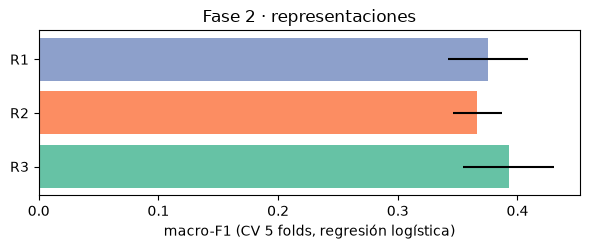

In [7]:
fig, ax = plt.subplots(figsize=(6, 2.6))
ax.barh(fase2.index, fase2['macro-F1'], xerr=fase2['± std'], color=['#8da0cb', '#fc8d62', '#66c2a5'])
ax.invert_yaxis(); ax.set_xlabel('macro-F1 (CV 5 folds, regresión logística)')
ax.set_title('Fase 2 · representaciones'); plt.tight_layout(); plt.show()

**La unión gana a sus dos partes:** R3 0.393 > R1 0.375 > R2 0.367.

| | Qué conserva | Qué pierde |
|---|---|---|
| **R1 · TF-IDF** (2171 dim.) | Qué palabras y pares de palabras aparecen, con peso según lo raras que son | El orden más allá del bigrama, tildes, emojis y mayúsculas (los borra `transformer()`). No relaciona `bueno` con `buenísimo` |
| **R2 · Léxica** (33 dim.) | Señales que BoW no ve: polaridad con negación, emojis, risas, groserías, cortesía, longitud y forma | Casi todo el contenido: dos tweets con los mismos conteos son idénticos |
| **R3 · Unión** (2204 dim.) | Las dos cosas | Hereda el ruido de ambas; las 33 columnas léxicas son el 1.5 % del espacio |

Las 33 columnas léxicas solas quedan a menos de 0.01 del TF-IDF con más de 2000 columnas.

## 4. Fase 3 — Selección del clasificador

Cuatro familias sobre la unión R3, cada una con su búsqueda de hiperparámetros por validación cruzada
estratificada de 5 folds (los mismos folds para todas). El sobremuestreo ocurre **dentro de cada fold**.

**Criterio de selección (fijado antes de ver resultados):** la mayor macro-F1 media en validación cruzada.

| Familia | Compatibilidad con la representación |
|---|---|
| Naive Bayes (Complement) | Exige valores no negativos → por eso MinMaxScaler. ComplementNB está pensado para clases desbalanceadas |
| Regresión logística (Softmax) | Es el clasificador del baseline; funciona bien en espacios dispersos |
| SVM lineal | Suele ser la mejor opción en alta dimensión dispersa (texto) |
| Random Forest | Cada árbol ve pocas columnas al azar; en miles de columnas TF-IDF casi vacías suele rendir peor |

In [8]:
FAMILIES = {
    'Naive Bayes (Complement)': (ComplementNB(), {'clf__alpha': [0.1, 0.3, 1.0, 3.0]}),
    'Regresión logística':      (LogisticRegression(max_iter=3000), {'clf__C': [0.1, 1.0, 10.0]}),
    'SVM lineal':               (LinearSVC(max_iter=20000), {'clf__C': [0.01, 0.1, 1.0]}),
    'Random Forest':            (RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=SEED),
                                 {'clf__max_depth': [None, 30], 'clf__min_samples_leaf': [1, 3]}),
}
searches, rows = {}, []
for name, (clf, grid) in FAMILIES.items():
    gs = GridSearchCV(model(representation('R3'), clf), grid, cv=CV, scoring='f1_macro', n_jobs=1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    i = gs.best_index_
    rows.append({'familia': name, 'mejores hiperparámetros': {k.replace('clf__', ''): v for k, v in gs.best_params_.items()},
                 'macro-F1 CV': gs.best_score_, '± std': gs.cv_results_['std_test_score'][i]})
fase3 = pd.DataFrame(rows).set_index('familia').sort_values('macro-F1 CV', ascending=False)
fase3[['macro-F1 CV', '± std']] = fase3[['macro-F1 CV', '± std']].round(4)
fase3

,mejores hiperparámetros,macro-F1 CV,± std
familia,,,
Random Forest,"{'max_depth': 30, 'min_samples_leaf': 3}",0.4314,0.0293
SVM lineal,{'C': 0.01},0.4017,0.0263
Naive Bayes (Complement),{'alpha': 0.1},0.3983,0.0336
Regresión logística,{'C': 0.1},0.3942,0.0235


Modelo elegido: Random Forest {'clf__max_depth': 30, 'clf__min_samples_leaf': 3}


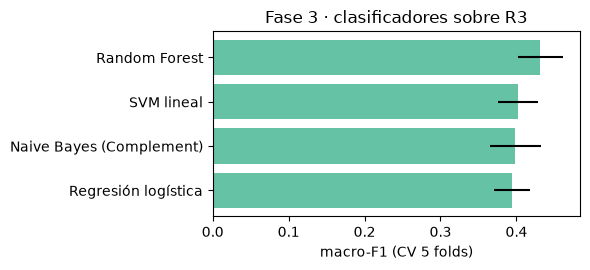

In [9]:
BEST = fase3.index[0]
best_model = searches[BEST].best_estimator_   # GridSearchCV ya lo reentrenó con TODO el train
print('Modelo elegido:', BEST, searches[BEST].best_params_)
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.barh(fase3.index, fase3['macro-F1 CV'], xerr=fase3['± std'], color='#66c2a5')
ax.invert_yaxis(); ax.set_xlabel('macro-F1 (CV 5 folds)'); ax.set_title('Fase 3 · clasificadores sobre R3')
plt.tight_layout(); plt.show()

**Elección: Random Forest** (max_depth = 30, min_samples_leaf = 3). Cumple el criterio fijado: la mayor
macro-F1 media en CV, **0.431**.

Su ventaja sobre SVM lineal (0.402) es de 0.030, del mismo tamaño que la desviación entre folds (≈ 0.03).
Es un indicio consistente, no una prueba estadística.

**Por qué Random Forest no rinde peor, como se esperaba en un espacio disperso.** Las columnas léxicas
densas (`lex_pol_neg`, `groserias`, `social_pos`) son justo donde un árbol corta bien por umbrales. Los
modelos lineales, en cambio, las diluyen entre 2204 columnas. La profundidad máxima y el mínimo de 3
tweets por hoja lo regularizan.

Naive Bayes funciona porque `MinMaxScaler` deja todo no negativo, pero su supuesto de independencia se
rompe con columnas léxicas correlacionadas entre sí.

## 5. Fase 4 — Ablación (sobre el train, con validación cruzada)

Quitamos cada característica nueva (o grupo) y medimos cuánto cae la macro-F1 del modelo elegido.
Un Δ negativo significa que la característica **ayudaba**. Se hace con CV sobre el train, nunca con test.

In [10]:
best_clf = searches[BEST].best_estimator_.named_steps['clf']
from sklearn.base import clone

def ablation_score(lex_cols):
    return cv_score(model(representation('R3', lex_cols), clone(best_clf)))

full = ablation_score(KEEP)
experiments = {'Sin ninguna característica nueva': [c for c in KEEP if c not in NEW_KEEP]}
for author, cols in AUTHORS.items():
    experiments[f'Sin {author}'] = [c for c in KEEP if c not in cols]
units = {'emoji_pol': ['emoji_count', 'emoji_pol'], 'laugh_count': ['laugh_count', 'laugh_len'],
         'lex_pol_neg': ['lex_pol_neg']}
units.update({c: [c] for c in NEW_KEEP if c not in sum(units.values(), [])})
for u, cols in units.items():
    experiments[f'  sin {u}'] = [c for c in KEEP if c not in cols]

rows = [{'experimento': 'Unión completa (referencia)', 'macro-F1': full['macro-F1'], '± std': full['± std'], 'Δ': 0.0}]
for name, cols in experiments.items():
    s = ablation_score(cols)
    rows.append({'experimento': name, 'macro-F1': s['macro-F1'], '± std': s['± std'], 'Δ': s['macro-F1'] - full['macro-F1']})
ablation = pd.DataFrame(rows).set_index('experimento').round(4)
ablation

,macro-F1,± std,Δ
experimento,,,
Unión completa (referencia),0.4314,0.0293,0.0000
Sin ninguna característica nueva,0.3900,0.0360,-0.0413
Sin Sebastian Sarmiento,0.4107,0.0280,-0.0206
Sin Zuly Gonzalez,0.4119,0.0328,-0.0194
Sin Daniel Contreras,0.4065,0.0197,-0.0249
sin emoji_pol,0.4281,0.0203,-0.0033
sin laugh_count,0.4162,0.0244,-0.0151
sin lex_pol_neg,0.4056,0.0259,-0.0257
sin doubt_count,0.4183,0.0383,-0.0130


**Quitar las 10 columnas nuevas cuesta 0.041 de macro-F1** (0.431 → 0.390): el trabajo del grupo aporta.

- **Por integrante:** Daniel −0.025, Sebastián −0.021, Zuly −0.019.
- **Por característica, de mayor a menor aporte:**

  | Característica | Autor | Aporte |
  |---|---|---|
  | `groserias` | Daniel | −0.029 |
  | `social_pos` | Daniel | −0.027 |
  | `lex_pol_neg` | Sebastián | −0.026 |
  | `intensifier_count` | Zuly | −0.022 |
  | `laugh_count` | Sebastián | −0.015 |
  | `doubt_count` | Zuly | −0.013 |
  | `regionalism_count` | Zuly | −0.011 |
  | `emoji_pol` | Sebastián | −0.003 |

**Cautela.** Cada Δ individual es menor o parecido a la desviación entre folds (0.02–0.04), así que el
orden entre ellas **no es concluyente**. Lo consistente es el signo: quitar cualquiera empeora el modelo.
Las tres que más aportan tienen una hipótesis de polaridad directa: insultos (N), cortesía (P) y
negación. `emoji_pol` casi no aporta porque solo el 3 % de los tweets tiene emojis.

### Segunda estrategia de unión

**A** (la usada hasta ahora): `ColumnTransformer` con las léxicas calculadas una vez y `MinMaxScaler`.
**B**: `FeatureUnion` que calcula todo **desde el tweet crudo dentro del pipeline** y escala las léxicas
con `StandardScaler` (media 0, desviación 1). B deja valores negativos, así que no sirve para Naive Bayes:
la comparación se hace con regresión logística y con SVM lineal.

In [11]:
def union_b(clf):
    text = Pipeline([('limpiar', FunctionTransformer(lambda X: [clean_text(t) for t in X])), ('tfidf', tfidf())])
    lexical = Pipeline([('lex', LexicalFeatures(columns=KEEP)), ('scale', StandardScaler())])
    return ImbPipeline([('features', FeatureUnion([('texto', text), ('lexico', lexical)])),
                        ('ros', RandomOverSampler(random_state=SEED)), ('clf', clf)])

rows = []
for name in ['Regresión logística', 'SVM lineal']:
    clf = searches[name].best_estimator_.named_steps['clf']
    a = cv_score(model(representation('R3'), clone(clf)))
    s = cross_validate(union_b(clone(clf)), train[COL_TEXT].to_numpy(), y_train, cv=CV, scoring='f1_macro')
    rows.append({'clasificador': name, 'A · ColumnTransformer + MinMax': a['macro-F1'],
                 'B · FeatureUnion + Standard': s['test_score'].mean(), '± std B': s['test_score'].std()})
estrategias = pd.DataFrame(rows).set_index('clasificador').round(4)
estrategias

,A · ColumnTransformer + MinMax,B · FeatureUnion + Standard,± std B
clasificador,,,
Regresión logística,0.3942,0.3909,0.0291
SVM lineal,0.4017,0.3814,0.0244


**La estrategia A gana con los dos clasificadores** (0.394 vs 0.391 con regresión logística; 0.402 vs
0.381 con SVM).

La causa es el escalado. `StandardScaler` deja las léxicas con valores de varias unidades (un conteo raro,
como `groserias`, puede valer 10 o más desviaciones), mientras que los pesos TF-IDF no pasan de 1. Así el
bloque léxico domina. `MinMaxScaler` pone los dos bloques en el mismo rango [0, 1].

## 6. Evaluación final en test (una sola vez)

A partir de aquí el modelo ya está elegido y no se cambia nada. Se carga el test por primera vez.
Como referencia se evalúa también el **baseline del taller** (BoW de 1–3 gramas + Softmax C=10 + sobremuestreo),
entrenado con el mismo train.

In [12]:
test = pd.read_csv(ROOT / 'data' / 'tass' / 'tass2018_es_test.csv').dropna(subset=[COL_TEXT]).reset_index(drop=True)
y_test = test[COL_LABEL].str.strip().str.upper().to_numpy()
X_test = pd.DataFrame(lex.transform(test[COL_TEXT]), columns=ALL_NAMES)
X_test['clean'] = [clean_text(t) for t in test[COL_TEXT]]
print(f'test: {len(test)} tweets', pd.Series(y_test).value_counts().reindex(CLASSES).to_dict())

baseline = ImbPipeline([('features', ColumnTransformer([('bow', CountVectorizer(ngram_range=(1, 3)), 'clean')])),
                        ('ros', RandomOverSampler(random_state=SEED)),
                        ('clf', LogisticRegression(C=10, max_iter=3000))])
baseline_cv = cv_score(baseline)
baseline.fit(X_train, y_train)

pred = best_model.predict(X_test)
pred_base = baseline.predict(X_test)

def bootstrap_ci(y, p, n=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    vals = [f1_score(y[s], p[s], average='macro') for s in (rng.integers(0, len(y), len(y)) for _ in range(n))]
    return np.percentile(vals, [2.5, 97.5])

rows = []
for name, p, cv in [(f'Baseline taller (BoW + Softmax)', pred_base, baseline_cv),
                    (f'Nuestro: {BEST} sobre R3', pred, {'macro-F1': searches[BEST].best_score_})]:
    lo, hi = bootstrap_ci(y_test, p)
    rows.append({'modelo': name, 'macro-F1 CV (train)': cv['macro-F1'], 'macro-F1 test': f1_score(y_test, p, average='macro'),
                 'IC 95 % inf': lo, 'IC 95 % sup': hi, 'accuracy test': accuracy_score(y_test, p)})
final = pd.DataFrame(rows).set_index('modelo').round(4)

# Bootstrap pareado: la misma muestra de tweets para los dos modelos
rng = np.random.default_rng(SEED)
diffs = [f1_score(y_test[s], pred[s], average='macro') - f1_score(y_test[s], pred_base[s], average='macro')
         for s in (rng.integers(0, len(y_test), len(y_test)) for _ in range(1000))]
lo, hi = np.percentile(diffs, [2.5, 97.5])
print(f'Mejora sobre el baseline: {np.mean(diffs):+.4f} macro-F1 (IC 95 % pareado: {lo:+.4f} a {hi:+.4f})')
final

test: 506 tweets {'N': 219, 'NEU': 69, 'NONE': 62, 'P': 156}


Mejora sobre el baseline: +0.0504 macro-F1 (IC 95 % pareado: +0.0071 a +0.0937)


,macro-F1 CV (train),macro-F1 test,IC 95 % inf,IC 95 % sup,accuracy test
modelo,,,,,
Baseline taller (BoW + Softmax),0.3556,0.3662,0.3236,0.4099,0.5158
Nuestro: Random Forest sobre R3,0.4314,0.4173,0.3727,0.4597,0.4980


              precision    recall  f1-score   support

           N      0.603     0.603     0.603       219
         NEU      0.240     0.174     0.202        69
        NONE      0.271     0.371     0.313        62
           P      0.559     0.545     0.552       156

    accuracy                          0.498       506
   macro avg      0.418     0.423     0.417       506
weighted avg      0.499     0.498     0.497       506



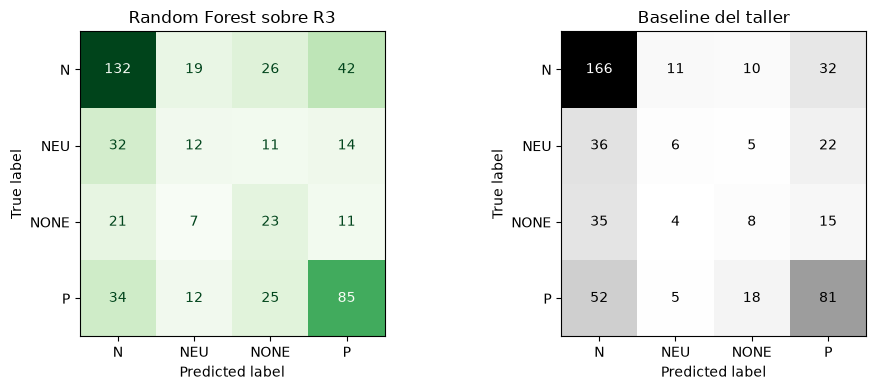

In [13]:
print(classification_report(y_test, pred, labels=CLASSES, digits=3, zero_division=0))
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, labels=CLASSES, ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title(f'{BEST} sobre R3')
ConfusionMatrixDisplay.from_predictions(y_test, pred_base, labels=CLASSES, ax=axes[1], colorbar=False, cmap='Greys')
axes[1].set_title('Baseline del taller')
plt.tight_layout(); plt.show()

**Resultado final en test: macro-F1 = 0.417** (IC 95 % bootstrap: 0.373–0.460), frente a **0.366** del
baseline del taller. La mejora es de **+0.050**, con un intervalo pareado (+0.007 a +0.094) que excluye el 0.

La accuracy baja un poco (0.498 vs 0.516) porque el baseline predice N casi siempre: acierta la clase
mayoritaria, pero solo 6 NEU y 8 NONE. Nuestro modelo acierta 12 NEU y 23 NONE, y eso es lo que premia
macro-F1.

- **Por clase:**

  | Clase | F1 | Qué pasa |
  |---|---|---|
  | N | 0.60 | Bien |
  | P | 0.55 | Bien |
  | NONE | 0.31 | Pocos ejemplos |
  | NEU | 0.20 | La peor |

- **Confusiones:** la mayor es N ↔ P (76 tweets entre las dos direcciones), seguida de NEU → N (32). NEU es
  por definición una mezcla de positivo y negativo, y solo tiene 133 ejemplos de train.

El resultado en test (0.417) es coherente con la CV (0.431): no hay señales de sobreajuste en la selección.

**Comparación con TASS 2018** (*Overview*, CEUR-WS vol. 2172, Tabla 4). El mejor sistema de InterTASS-ES
(ELiRF-UPV) obtuvo **macro-F1 = 0.503** y accuracy = 0.612. **No es directamente comparable:** según la
Tabla 1 del Overview, nuestro conjunto de evaluación (506 tweets: 219 N, 156 P, 69 NEU, 62 NONE) es la
partición **Dev**, no el test oficial de 1899 tweets. Como orientación, nuestro sistema clásico queda
≈ 0.09 por debajo del mejor participante, que usaba modelos neuronales.

## 7. Análisis de errores

Tweets reales del test mal clasificados por el modelo elegido. Los leímos uno a uno y los agrupamos por tipo de error.

In [14]:
errors = test.assign(real=y_test, predicho=pred)[y_test != pred][['tweetid', 'real', 'predicho', COL_TEXT]]
print(f'{len(errors)} errores de {len(test)} tweets ({len(errors) / len(test):.0%})')
pd.crosstab(errors['real'], errors['predicho'])

254 errores de 506 tweets (50%)


predicho,N,NEU,NONE,P
real,,,,
N,0,19,26,42
NEU,32,0,11,14
NONE,21,7,0,11
P,34,12,25,0


In [15]:
ERROR_TYPES = {
    770262568703291392: 'Humor o ironía',
    770711642971734016: 'Humor o ironía',
    770459663859146752: 'Humor o ironía',
    773650684386443266: 'Negación mal resuelta',
    770680542522183680: 'Negación mal resuelta',
    770114408467095552: 'Negación mal resuelta',
    769653702554681345: 'Polaridad mixta (contraste)',
    772818960173719552: 'Polaridad mixta (contraste)',
    768163226240647168: 'Polaridad mixta (contraste)',
    772816974388887553: 'Polaridad mixta (contraste)',
    757593585634213888: 'Polaridad mixta (contraste)',
    771386037214048256: 'Polaridad mixta (contraste)',
    770269426834894850: 'Polaridad implícita, sin palabras de opinión',
    770470969085464578: 'Polaridad implícita, sin palabras de opinión',
    770561721157255168: 'Polaridad implícita, sin palabras de opinión',
    770221197309120512: 'Variantes de lengua o de escritura',
    770208079099072512: 'Variantes de lengua o de escritura',
}

sample = errors[errors['tweetid'].isin(ERROR_TYPES)].copy()
sample['tipo de error'] = sample['tweetid'].map(ERROR_TYPES)
sample[COL_TEXT] = sample[COL_TEXT].str.replace(r'\s+', ' ', regex=True)
print(sample['tipo de error'].value_counts().to_string(), '\n')
sample.sort_values('tipo de error')[['tipo de error', 'real', 'predicho', COL_TEXT]]

tipo de error
Polaridad mixta (contraste)                     6
Polaridad implícita, sin palabras de opinión    3
Humor o ironía                                  3
Negación mal resuelta                           3
Variantes de lengua o de escritura              2 



,tipo de error,real,predicho,content
47,Humor o ironía,NEU,P,@LorasTyrellSer Yo también te puse algo bonito. Cuanto desprecio
177,Humor o ironía,NONE,N,@thorelvasco @PabloGenis yo no me tiro pedos soy un princeso
235,Humor o ironía,N,P,@henryancat tio es que esta el librillo recien comprao der chino y me toca la polla 😂😂 vente pa casa te do...
146,Negación mal resuelta,P,N,La persona vale para algo. Otra cosa es que no te creas lo maravilloso y ese arte que puedes desplegar..fi...
223,Negación mal resuelta,P,N,"Cuando no puedo dormir, escribo todo lo que preocupa en una libreta que alguien me regaló y es como un som..."
454,Negación mal resuelta,NONE,N,@Pattvh_ no porque no los tienes activados a todos
17,"Polaridad implícita, sin palabras de opinión",P,NONE,Cosas que enamora las tostadas calentitas a estas horas de la mañana
46,"Polaridad implícita, sin palabras de opinión",P,N,Despues de trabajar duro me merezco mis caprichos
261,"Polaridad implícita, sin palabras de opinión",NEU,NONE,"Último dia en Elche, ahora toca Benidorm"
348,Polaridad mixta (contraste),NEU,N,"Creo que pocas veces he estado tan enfadado como esta mañana, pero bueno, entre Uncharted 4 y el ejercicio..."


**Tipos de error** (17 tweets leídos a mano):

1. **Polaridad mixta o contraste (6), el más frecuente.** *"Creo que pocas veces he estado tan enfadado
   como esta mañana, pero bueno, entre Uncharted 4 y el ejercicio me han animado"* (real NEU, predicho N):
   el modelo se queda con `enfadado` e ignora la segunda mitad.
2. **Humor o ironía (3).** *"…me toca la polla 😂😂 vente pa casa"* (N → P): la risa y el tono de broma
   tapan la queja. En *"Yo también te puse algo bonito. Cuanto desprecio"* (NEU → P) domina `bonito`.
3. **Negación mal resuelta (3).** *"no porque no los tienes activados a todos"* (NONE → N): dos "no"
   sin ninguna opinión. En *"no te creas lo maravilloso…"* (P → N), la negación no invierte el sentido
   positivo.
4. **Polaridad implícita (3).** *"Después de trabajar duro me merezco mis caprichos"* (P → N): la
   opinión depende del conocimiento del mundo, no de palabras de opinión.
5. **Variantes de lengua o de escritura (2).** *"Correcció 'Nin se nos pasa pola cabeza NON ser
   segundos'"* está en gallego. En *"no sé, estaría guay"* (P → N), la duda y la negación pesan más que
   `guay`.

## 8. Limitaciones

- **Desbalance:** NEU y NONE tienen unos 135 ejemplos de train cada una. Su F1 es inestable y es donde
  queda el mayor margen de mejora.
- **Ironía y humor:** las características léxicas miden la forma, no la intención.
- **Variación dialectal:** la lista de regionalismos mezcla variedades (colombiana, mexicana,
  argentina) con palabras generales de España; TASS ES es peninsular.
- **Dependencia del léxico:** ML-SentiCon trabaja con lemas (`gusta` no está, `gustar` sí); las listas
  de groserías, cortesía e intensificadores son cerradas.
- **Dominio y tamaño:** tweets de 2016 y solo 1008 ejemplos de train. Diferencias menores de ≈ 0.03
  no son demostrables.

## 9. Conclusión

1. **La unión TF-IDF + características léxicas del grupo supera a cada representación por separado** y
   mejora el baseline del taller de 0.366 a **0.417** de macro-F1 en test, con un intervalo pareado
   que excluye el 0.
2. **Algoritmo elegido: Random Forest** sobre la unión, por el criterio explícito de la mayor macro-F1
   en CV (0.431). SVM lineal queda segundo (0.402).
3. **Las características que más aportan son las de polaridad directa:** groserías y cortesía
   (Daniel), negación con alcance (Sebastián) e intensificadores (Zuly).
4. El techo está en **NEU** y en el **humor/ironía**, que requieren información que no está en las
   palabras sueltas.